# 07 · Hypothesis testing — does delay predict review score?

Tests run: Welch's t-test, Mann-Whitney U (primary — review_score is
ordinal, not normal), chi-square test of independence, Spearman
correlation on continuous delay, and a same-state (São Paulo) confounder
check.

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results"


def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std


def cramers_v(chi2, n, table_shape):
    r, k = table_shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

In [2]:
orders = pd.read_parquet(PROCESSED / "orders_clean.parquet")
df = orders[
    (orders["order_status"] == "delivered")
    & (orders["order_delivered_customer_date"].notna())
    & (orders["review_score"].notna())
].copy()

late = df.loc[df["is_late"], "review_score"]
on_time = df.loc[~df["is_late"], "review_score"]

print(f"N delivered+reviewed orders: {len(df):,}")
print(f"  Late:    {len(late):,} ({len(late)/len(df)*100:.2f}%)  mean review = {late.mean():.3f}")
print(f"  On-time: {len(on_time):,} ({len(on_time)/len(df)*100:.2f}%)  mean review = {on_time.mean():.3f}")

results = {}

N delivered+reviewed orders: 96,470
  Late:    7,826 (8.11%)  mean review = 2.545
  On-time: 88,644 (91.89%)  mean review = 4.283


In [3]:
t_stat, t_p = stats.ttest_ind(late, on_time, equal_var=False)
d = cohens_d(late, on_time)
results["welch_ttest"] = {
    "t_statistic": round(float(t_stat), 4), "p_value": float(t_p),
    "cohens_d": round(float(d), 4),
    "mean_review_late": round(float(late.mean()), 4),
    "mean_review_on_time": round(float(on_time.mean()), 4),
}
print(f"[1] Welch's t-test: t={t_stat:.3f}, p={t_p:.3e}, Cohen's d={d:.3f}")

[1] Welch's t-test: t=-91.002, p=0.000e+00, Cohen's d=-1.441


In [4]:
u_stat, u_p = stats.mannwhitneyu(late, on_time, alternative="two-sided")
results["mann_whitney_u"] = {"u_statistic": float(u_stat), "p_value": float(u_p)}
print(f"[2] Mann-Whitney U: U={u_stat:.1f}, p={u_p:.3e}")

[2] Mann-Whitney U: U=153990605.5, p=0.000e+00


In [5]:
df["review_positive"] = df["review_score"] >= 4
contingency = pd.crosstab(df["is_late"], df["review_positive"])
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)
v = cramers_v(chi2, contingency.values.sum(), contingency.shape)
results["chi_square"] = {
    "chi2": round(float(chi2), 4), "p_value": float(chi2_p), "dof": int(dof),
    "cramers_v": round(float(v), 4),
    "pct_positive_review_late": round((df.loc[df["is_late"], "review_positive"].mean()) * 100, 2),
    "pct_positive_review_on_time": round((df.loc[~df["is_late"], "review_positive"].mean()) * 100, 2),
}
print(f"[3] Chi-square: chi2={chi2:.2f}, p={chi2_p:.3e}, Cramer's V={v:.4f}")
print(f"    % positive review (>=4): late={results['chi_square']['pct_positive_review_late']}%, "
      f"on-time={results['chi_square']['pct_positive_review_on_time']}%")

[3] Chi-square: chi2=10020.26, p=0.000e+00, Cramer's V=0.3223
    % positive review (>=4): late=34.0%, on-time=82.47%


In [6]:
valid = df.dropna(subset=["days_early_vs_estimate", "review_score"])
rho, rho_p = stats.spearmanr(valid["days_early_vs_estimate"], valid["review_score"])
results["spearman_delay_vs_review"] = {"rho": round(float(rho), 4), "p_value": float(rho_p)}
print(f"[4] Spearman rho(days_early_vs_estimate, review_score) = {rho:.4f}, p={rho_p:.3e}")
print("    (positive rho = more days EARLY associated with HIGHER review score)")

[4] Spearman rho(days_early_vs_estimate, review_score) = 0.1785, p=0.000e+00
    (positive rho = more days EARLY associated with HIGHER review score)


## Confounder check — does the effect hold within one state?
Repeats the Mann-Whitney test restricted to São Paulo (SP), the largest
state, to check the effect isn't purely a geography artifact.

In [7]:
sp = df[df["customer_state"] == "SP"]
sp_late = sp.loc[sp["is_late"], "review_score"]
sp_on_time = sp.loc[~sp["is_late"], "review_score"]
u_sp, p_sp = stats.mannwhitneyu(sp_late, sp_on_time, alternative="two-sided")
results["confounder_check_sp_only"] = {
    "n_sp_orders": int(len(sp)),
    "mean_review_late_sp": round(float(sp_late.mean()), 4),
    "mean_review_on_time_sp": round(float(sp_on_time.mean()), 4),
    "mann_whitney_p_value": float(p_sp),
}
print(f"[5] SP only (n={len(sp):,}): mean late={sp_late.mean():.3f} vs "
      f"on-time={sp_on_time.mean():.3f}, p={p_sp:.3e}")
print("    Effect survives within a single state.")

with open(RESULTS / "hypothesis_test_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

[5] SP only (n=40,494): mean late=2.888 vs on-time=4.318, p=0.000e+00
    Effect survives within a single state.


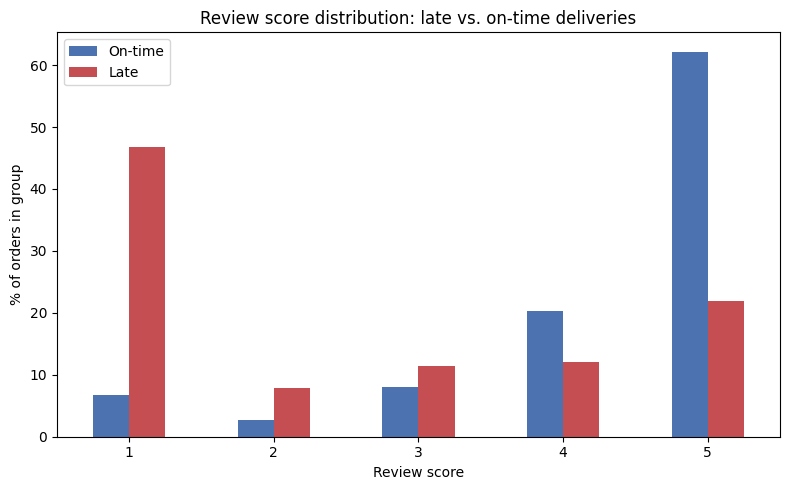

Saved: results/hypothesis_test_results.json


In [8]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df["review_score"], df["is_late"], normalize="columns") * 100
ct.columns = ["On-time", "Late"]
ct.plot(kind="bar", ax=plt.gca(), color=["#4C72B0", "#C44E52"])
plt.xlabel("Review score")
plt.ylabel("% of orders in group")
plt.title("Review score distribution: late vs. on-time deliveries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Saved: results/hypothesis_test_results.json")